In [7]:
import h5py
import numpy as np
import faiss
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import skew



def load_embeddings(path):
    ids, embeddings = [], []
    with h5py.File(path, "r") as hf:
        for key in hf.keys():
            vec = np.empty(hf[key].shape, dtype='float32')
            hf[key].read_direct(vec)
            ids.append(key)
            embeddings.append(vec)
    return ids, np.array(embeddings).astype('float32')

def get_fasta_lengths(fasta_path):
    lengths = {}
    with open(fasta_path, 'r') as f:
        curr_id, curr_seq = None, ""
        for line in f:
            line = line.strip()
            if not line: continue
            if line.startswith('>'):
                if curr_id: lengths[curr_id] = len(curr_seq)
                # Nettoyage UniProt sp|ID|NAME -> ID
                full_id = line.split()[0][1:]
                curr_id = full_id.split('|')[1] if '|' in full_id else full_id
                curr_seq = ""
            else: curr_seq += line
        if curr_id: lengths[curr_id] = len(curr_seq)
    return lengths

def clean_id(protein_id):
    return protein_id.split('|')[1] if '|' in protein_id else protein_id

In [13]:
def run_full_analysis(path1, path2, fasta1, fasta2, output_name="Analysis"):
    # 1. Chargement
    id1, emb1 = load_embeddings(path1)
    id2, emb2 = load_embeddings(path2)
    len_dict = {**get_fasta_lengths(fasta1), **get_fasta_lengths(fasta2)}
    
    # 2. Similarité Cosinus avec FAISS
    faiss.normalize_L2(emb1)
    faiss.normalize_L2(emb2)
    
    index2 = faiss.IndexFlatIP(emb2.shape[1])
    index2.add(emb2)
    sim1_2, _ = index2.search(emb1, k=1)
    
    index1 = faiss.IndexFlatIP(emb1.shape[1])
    index1.add(emb1)
    sim2_1, _ = index1.search(emb2, k=1)
    
    # 3. Création du DataFrame
    df = pd.concat([
        pd.DataFrame({'ID': [clean_id(i) for i in id1], 'Sim': sim1_2.flatten(), 'Group': 'Org1'}),
        pd.DataFrame({'ID': [clean_id(i) for i in id2], 'Sim': sim2_1.flatten(), 'Group': 'Org2'})
    ])
    
    # 4. Statistiques et Outliers (Seuil 3-sigma)
    mean_s, std_s = df['Sim'].mean(), df['Sim'].std()
    cutoff = mean_s - (3 * std_s)
    df['is_outlier'] = df['Sim'] < cutoff
    df['Length'] = df['ID'].map(len_dict)
    
    # 5. Affichage des Distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphe 1 : Distribution de Similarité
    sns.kdeplot(data=df, x="Sim", fill=True, ax=ax1, color="royalblue")
    ax1.legend()
    
    # Graphe 2 : Comparaison de Longueur
    sns.histplot(data=df, x="Length", hue="is_outlier", element="step", ax=ax2)
    ax2.set_xlim(0, 2000)
    ax2.set_title("Distribution de la longueur sur les Outliers")
    
    plt.tight_layout()
    plt.show()
    
    # Stats finales
    outliers = df[df['is_outlier']]
    print(f"--- RÉSULTATS : {output_name} ---")
    print(f"Nombre d'outliers : {len(outliers)}")
    print(f"Moyenne Longueur Protéome : {df['Length'].mean():.1f} AA")
    print(f"Moyenne Longueur Outliers : {outliers['Length'].mean():.1f} AA")
    
    return df, outliers

In [14]:
print(cutoff)

NameError: name 'cutoff' is not defined

/tmp/ipykernel_3077663/4201087737.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


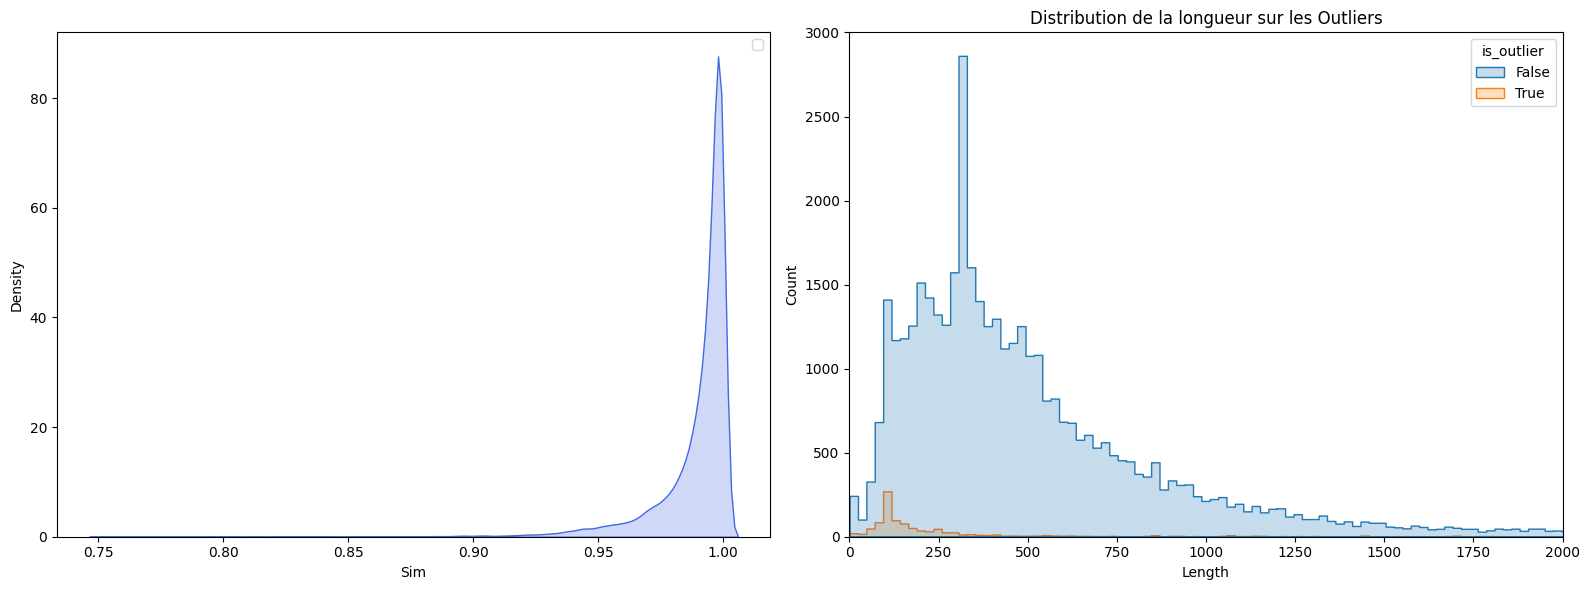

--- RÉSULTATS : Test_Nouvelle_Methode ---
Nombre d'outliers : 945
Moyenne Longueur Protéome : 547.0 AA
Moyenne Longueur Outliers : 292.2 AA


In [9]:
# Chemins à changer pour tes futurs essais
p1 = "/home/cassandre/stage/Cassandre/Embeddings/ESMC600_EMBEDDING/homosapiens_esmc600_embedding.h5.h5"
p2 = "/home/cassandre/stage/Cassandre/Embeddings/ESMC600_EMBEDDING/mus_esmc600_embedding.h5.h5"
f1 = "/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000000589_10090.fa"
f2 = "/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000005640_9606.fa"

# Lancement automatique
df_final, mes_outliers = run_full_analysis(p1, p2, f1, f2, "Test_Nouvelle_Methode")

# Sauvegarde des IDs pour PantherDB si besoin
# mes_outliers['ID'].to_csv("mes_outliers.txt", index=False, header=False)

This code is to compare the overlap between 2 Outliers txt list with the jaccard method

In [1]:
def compare_outliers(file_path_1, file_path_2):
    # 1. Charger les IDs dans des sets (pour la vitesse et les opérations mathématiques)
    with open(file_path_1, 'r') as f:
        set1 = {line.strip() for line in f if line.strip()}
    
    with open(file_path_2, 'r') as f:
        set2 = {line.strip() for line in f if line.strip()}

    # 2. Calculer l'intersection (l'overlap)
    overlap = set1.intersection(set2)
    
    # 3. Calculer ce qui est spécifique à chaque fichier
    only_in_1 = set1 - set2
    only_in_2 = set2 - set1

    # 4. Affichage des résultats
    print(f"--- COMPARAISON DES OUTLIERS ---")
    print(f"Fichier 1 ({file_path_1.split('/')[-1]}) : {len(set1)} IDs")
    print(f"Fichier 2 ({file_path_2.split('/')[-1]}) : {len(set2)} IDs")
    print("-" * 30)
    print(f"Overlap (IDs communs) : {len(overlap)}")
    
    if len(overlap) > 0:
        print(f"Exemples d'overlap : {list(overlap)[:5]}")
        
    # Calcul du pourcentage d'overlap (Indice de Jaccard)
    if len(set1 | set2) > 0:
        jaccard = len(overlap) / len(set1 | set2) * 100
        print(f"Indice de similitude : {jaccard:.2f}%")

# Chemins vers tes fichiers (adapte si besoin)
outliers1 = "/home/cassandre/stage/Cassandre/UMAP_ESMCEMBEDDINGS/ESMC300M/outlierslist_text/outliers_homosapiens.txt"
outliers2 = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/human_mouseoutliers_homosapiens.txt"

compare_outliers(outliers1, outliers2)

--- COMPARAISON DES OUTLIERS ---
Fichier 1 (outliers_homosapiens.txt) : 483 IDs
Fichier 2 (human_mouseoutliers_homosapiens.txt) : 619 IDs
------------------------------
Overlap (IDs communs) : 132
Exemples d'overlap : ['Q5T7P6', 'P0C7X4', 'A0A0A0MT82', 'Q53H47', 'A5A3E0']
Indice de similitude : 13.61%
